In [1]:
"""SHARED FIGURE STYLE -- run first."""
import sys, pathlib


def _find_paper_style():
    here = pathlib.Path.cwd().resolve()
    for cand in [here, *here.parents]:
        if (cand / 'paper_style.py').exists():
            return cand
        if (cand / 'paper-individuality' / 'paper_style.py').exists():
            return cand / 'paper-individuality'
    raise FileNotFoundError(f'paper_style.py not found above {here}')


_root = _find_paper_style()
for _p in (str(_root), str(_root / 'learning_individuality'),
           str(_root / 'learning_individuality' / 'wheel')):
    if _p not in sys.path:
        sys.path.insert(0, _p)
import paper_style as ps

ps.use('paper')

paper_style: paper mode, spines=lb, font 7 pt, panels 3.4x2.4 in, save 400 dpi


'paper'

In [2]:
"""
DOES MOVEMENT VIGOR IN EARLY TRAINING PREDICT MOVEMENT VIGOR WHEN PROFICIENT?
=============================================================================
The simplest form of the individuality question, on the wheel alone.

WHY A SCALAR RATHER THAN A PROFILE
    early_proficient_shared_subspace.ipynb compared 40-dimensional time-warped
    profiles and could not resolve the question: an observed correlation is the true
    one shrunk by sqrt(rel_X * rel_Y), and a 40-number profile built from ~200 early
    trials is badly estimated in every dimension. A scalar pools the whole session
    into one number. Nothing about the biology differs -- only how well it is
    measured, and that turned out to be the binding constraint.

WHAT IS BYPASSED
    No go-cue alignment, no epoch labelling, no time warping. Those answer WHEN in a
    trial something happens; this asks HOW MUCH the animal moves overall. It also
    skips align_bin_design_matrix, the slowest step in the pipeline.

CONFOUNDS HANDLED IN wheel_vigor.py
    * 30 Hz (training) vs 60 Hz (proficient) sampling. Averaging over a bin twice as
      long smooths the trace, which mechanically lowers any threshold-crossing or
      extreme-value statistic. Every session is resampled onto a common 30 Hz grid.
      Rates turned out uniform WITHIN each source, so this injects no between-mouse
      noise -- but that is verified below rather than assumed.
    * |velocity| spikes ~50x the 95th percentile -> winsorised at 99.5%.
    * sessions differ in length -> every metric is a rate or a distributional
      summary, never a total.

A CONFOUND THAT IS NOT ONE
    Rig identity. Rigs change between training and recording, so a shared rig cannot
    manufacture this correlation -- it can only attenuate one.
"""
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr, pearsonr

import wheel_vigor as wv
import wheel_preprocessing as wp

In [3]:
"""
PRE-REGISTRATION -- fixed before the confirmatory tests were computed
=====================================================================
Eleven metrics exist and most are near-redundant. Testing all of them and reporting
the best would be the trap this cell exists to avoid.

CO-PRIMARY -- two, because the prediction has two genuinely different parts:
    frac_moving        HOW MUCH OF THE TIME the animal engages the wheel
    mean_speed_moving  HOW HARD it pushes GIVEN that it is moving
  Holm over these two and nothing else.

  WHY mean_speed_moving AND NOT mean_speed. mean_speed averages over the still
  samples too, so it mixes the two constructs: it correlates 0.84 with frac_moving.
  Conditioning on movement makes the two orthogonal (rho 0.03) and raises split-half
  reliability from 0.54 to 0.62. The switch was made on those two grounds -- construct
  separation and reliability -- BEFORE its correlation with the early session was
  looked at, which is what keeps it an a priori choice rather than a peek-driven one.

  (median_speed was considered and rejected: the median sits below the movement
  threshold in 97-100% of sessions, so it measures baseline stillness, not vigor, and
  it correlates 0.92 with frac_moving -- two co-primaries measuring one thing.)

SECONDARY -- Holm over these two:  bout_rate_per_min, turn_bias
EXPLORATORY -- the rest. Shown, but no inferential claim.

ONE-TAILED, and this is a commitment with a cost. The prediction is directional, so
only a POSITIVE correlation can support it; a strong negative one would refute the
hypothesis and would have to be re-tested as a new two-tailed question.

NOT hypothesis tests, so multiplicity does not apply: reliability / noise ceiling,
the confound checks, and the LD1 premise check.
"""
PRIMARY = ['frac_moving', 'mean_speed_moving']
SECONDARY = ['bout_rate_per_min', 'turn_bias']
METRICS = list(wv.METRICS)
EXPLORATORY = [m for m in METRICS if m not in PRIMARY + SECONDARY]

ALPHA = 0.05
TAILS = 'one'
METHOD = 'spearman'
MIN_PROF_CEILING = 2

print(f'CO-PRIMARY  {PRIMARY}  (Holm over {len(PRIMARY)})')
print(f'SECONDARY   {SECONDARY}  (Holm over {len(SECONDARY)})')
print(f'EXPLORATORY {EXPLORATORY}')
print(f'\nalpha {ALPHA} | {TAILS}-tailed (directional) | {METHOD}')

CO-PRIMARY  ['frac_moving', 'mean_speed_moving']  (Holm over 2)
SECONDARY   ['bout_rate_per_min', 'turn_bias']  (Holm over 2)
EXPLORATORY ['mean_speed', 'median_speed', 'p95_speed', 'sd_speed', 'mean_bout_s', 'distance_per_min', 'mean_vel_signed']

alpha 0.05 | one-tailed (directional) | spearman


In [4]:
"""
LOAD -- three cached builds, all produced by wheel_vigor.build_vigor
====================================================================
vigor_sessions.parquet          each mouse's FIRST-ever training session + all of
                                its proficient sessions
vigor_sessions_second.parquet   each mouse's SECOND training session

The second-session build is what makes early reliability measurable ACROSS sessions
for the first time; every previous attempt at this question had one early session per
mouse and could only split within it.
"""
V = pd.read_parquet('vigor_sessions.parquet')
S2 = pd.read_parquet('vigor_sessions_second.parquet')

print(V.groupby('source').agg(sessions=('session', 'size'),
                              mice=('mouse_name', 'nunique')).to_string())
print(f'second training sessions: {len(S2)} ({S2.mouse_name.nunique()} mice)')

print('\nsampling rate actually seen (the resampling assumption, made checkable):')
print(V.assign(hz=V['sampling_hz'].round(0)).groupby(['source', 'hz']).size().to_string())
print('-> uniform within each source, so resampling removes the 30/60 Hz difference')
print('   without injecting between-mouse noise.')

print('\nsession duration (min):')
print(V.groupby('source')['duration_min'].describe()[['mean', '50%', 'min', 'max']].round(1).to_string())

FIRST = V.loc[V['source'] == 'training'].set_index('mouse_name')
PROF = V.loc[V['source'] == 'proficient']
N_PROF = PROF.groupby('mouse_name').size()
PROF_M = PROF.groupby('mouse_name')[METRICS].mean()
SECOND = S2.set_index('mouse_name')
BOTH = sorted(set(FIRST.index) & set(SECOND.index))
print(f'\nmice with first AND second training session: {len(BOTH)}')

            sessions  mice
source                    
proficient       313   101
training         101   101
second training sessions: 96 (96 mice)

sampling rate actually seen (the resampling assumption, made checkable):
source      hz  
proficient  60.0    313
training    30.0    101
-> uniform within each source, so resampling removes the 30/60 Hz difference
   without injecting between-mouse noise.

session duration (min):
            mean   50%   min    max
source                             
proficient  76.9  75.1  35.8  121.8
training    59.9  51.6  20.5  100.9

mice with first AND second training session: 96


## The noise ceiling — what it is, and why it decides the interpretation

Every measurement is the true value plus noise. Correlating *two* noisy measurements
shrinks the answer:

```
r_observed  =  r_true  ×  sqrt( reliability_early × reliability_proficient )
```

So even a **perfectly** stable trait could not show more than `sqrt(rel_early × rel_prof)`.
That is the **ceiling**. Comparing rho to 1.0 is meaningless; comparing it to the ceiling
is the question.

**Worked example.** rel_early 0.50, rel_prof 0.80 → ceiling `sqrt(0.40)` = 0.63. Observing
rho = 0.32 is then not "weak" — it is `0.32/0.63` ≈ 0.51 of the maximum, a trait about
half stable.

**How each side is estimated here — and why this notebook can do something the earlier
ones could not.**

*Proficient:* split a mouse's sessions into two halves, average each, correlate across
mice. The halves share no session, so session-level nuisance counts as noise. Spearman–
Brown then steps the estimate from "half the sessions" to "all of them": `2r/(1+r)`.

*Early:* **session 1 against session 2** — two genuinely different days. Every previous
version of this analysis (including the syllable notebooks) had one early session per
mouse and could only split *within* it, which shares rig, day, handling and state and so
inflates reliability by an unknown amount. Loading the second session removes that
guesswork.

**Why that matters more than the extra power.** With an honest early reliability, a small
correlation becomes interpretable. If the ceiling is high and rho is low, the trait is
genuinely weak — not merely unmeasured. That distinction is what blocked every earlier
attempt at this question.

In [5]:
"""
RELIABILITY AND THE CEILING -- computed before the tests, so that "not measurable"
is a prediction rather than an alibi for a disappointing result.
"""
def spearman_brown(r):
    return 2 * r / (1 + r) if r > -1 else np.nan


def prof_reliability(n_rep=300, min_prof=MIN_PROF_CEILING, seed=0):
    """Split-half ACROSS proficient sessions -- the halves share no session."""
    rng = np.random.default_rng(seed)
    mice = sorted(N_PROF[N_PROF >= min_prof].index)
    acc = {m: [] for m in METRICS}
    for _ in range(n_rep):
        A, B = {}, {}
        for mm in mice:
            s = PROF.loc[PROF['mouse_name'] == mm]
            i = rng.permutation(len(s)); c = max(1, len(s) // 2)
            A[mm] = s.iloc[i[:c]][METRICS].mean()
            B[mm] = s.iloc[i[c:]][METRICS].mean()
        dA, dB = pd.DataFrame(A).T, pd.DataFrame(B).T
        for m in METRICS:
            ok = dA[m].notna() & dB[m].notna()
            if ok.sum() > 5:
                acc[m].append(spearmanr(dA.loc[ok, m], dB.loc[ok, m])[0])
    return pd.Series({m: np.nanmean(v) for m, v in acc.items()}), len(mice)


REL_P_RAW, N_P = prof_reliability()
REL_P = REL_P_RAW.apply(spearman_brown)

# early: session 1 vs session 2, two different days
REL_E_RAW = pd.Series({m: spearmanr(FIRST.loc[BOTH, m], SECOND.loc[BOTH, m],
                                    nan_policy='omit')[0] for m in METRICS})
REL_E = REL_E_RAW.apply(spearman_brown)      # reliability of the MEAN of two sessions
CEILING = np.sqrt(np.clip(REL_E, 0, 1) * np.clip(REL_P, 0, 1))

print(f'early = session 1 vs session 2 ({len(BOTH)} mice) | '
      f'proficient = split-half across sessions ({N_P} mice)\n')
print(f'{"metric":22s} {"s1 vs s2":>9s} {"SB(2 sess)":>11s} {"prof SB":>8s} {"ceiling":>8s}')
for m in METRICS:
    mark = ' *' if m in PRIMARY else ''
    print(f'{m:22s} {REL_E_RAW[m]:9.3f} {REL_E[m]:11.3f} {REL_P[m]:8.3f} {CEILING[m]:8.3f}{mark}')
print('\n* = co-primary. Early reliability is HONEST here (different days), not the')
print('  inflated within-session figure every earlier version of this analysis used.')

early = session 1 vs session 2 (96 mice) | proficient = split-half across sessions (74 mice)

metric                  s1 vs s2  SB(2 sess)  prof SB  ceiling
mean_speed                 0.618       0.764    0.818    0.791
mean_speed_moving          0.462       0.632    0.890    0.750 *
median_speed               0.645       0.784    0.745    0.764
p95_speed                  0.541       0.702    0.850    0.772
sd_speed                   0.518       0.682    0.850    0.761
frac_moving                0.660       0.795    0.749    0.771 *
bout_rate_per_min          0.677       0.807    0.769    0.788
mean_bout_s                0.412       0.584    0.876    0.715
distance_per_min           0.618       0.764    0.818    0.791
mean_vel_signed            0.555       0.714    0.857    0.782
turn_bias                  0.572       0.727    0.836    0.780

* = co-primary. Early reliability is HONEST here (different days), not the
  inflated within-session figure every earlier version of this analysi

In [6]:
"""
THE TESTS
==========
Two versions, reported side by side and clearly labelled:

  REGISTERED    early = the FIRST session only. This is the pre-specified analysis.
  SENSITIVITY   early = the MEAN of sessions 1 and 2. Averaging raises early
                reliability and therefore the ceiling, so this has more power -- but
                it was added AFTER interim results had been seen, so it is reported
                as a sensitivity analysis and never as the registered result.

Both are one-tailed with Holm applied within each family.
"""
def holm(p):
    p = np.asarray(p, float); order = np.argsort(p)
    adj = np.empty_like(p); run = 0.0
    for i, j in enumerate(order):
        run = max(run, (len(p) - i) * p[j]); adj[j] = min(run, 1.0)
    return adj


def corr(x, y, tails=TAILS, method=METHOD):
    x = np.asarray(x, float); y = np.asarray(y, float)
    ok = np.isfinite(x) & np.isfinite(y)
    fn = spearmanr if method == 'spearman' else pearsonr
    r, p = fn(x[ok], y[ok])
    if tails == 'one':
        p = p / 2 if r > 0 else 1 - p / 2
    return r, p, int(ok.sum())


def run_block(title, early, cohort):
    print('=' * 76)
    print(f'{title}   ({len(cohort)} mice)')
    tables = {}
    for name, mets in [('CO-PRIMARY', PRIMARY), ('SECONDARY', SECONDARY)]:
        res = [corr(early.loc[cohort, m], PROF_M.loc[cohort, m]) for m in mets]
        adj = holm([x[1] for x in res])
        print(f'  {name:20s} {"rho":>7s} {"p 1-tail":>9s} {"Holm":>8s} '
              f'{"ceiling":>8s} {"rho/ceil":>9s}')
        rows = []
        for m, (r, p, n), pa in zip(mets, res, adj):
            c = CEILING[m]
            ok = pa < ALPHA and r > 0
            print(f'  {m:20s} {r:+7.3f} {p:9.4g} {pa:8.4g} {c:8.3f} '
                  f'{(r / c if c > 0 else np.nan):+9.3f}' + ('   SUPPORTED' if ok else ''))
            rows.append(dict(metric=m, rho=r, p=p, holm=pa, ceiling=c,
                             corrected=r / c if c > 0 else np.nan, supported=ok))
        tables[name] = pd.DataFrame(rows)
    print(f'  {"EXPLORATORY":20s} {"rho":>7s} {"p 1-tail":>9s}')
    for m in EXPLORATORY:
        r, p, n = corr(early.loc[cohort, m], PROF_M.loc[cohort, m])
        print(f'  {m:20s} {r:+7.3f} {p:9.4g}')
    return tables


COH1 = sorted(set(FIRST.index) & set(PROF_M.index))
REG = run_block('REGISTERED -- first session only', FIRST, COH1)

EARLY2 = (pd.concat([FIRST.loc[BOTH, METRICS], SECOND.loc[BOTH, METRICS]])
          .groupby(level=0).mean())
COH2 = sorted(set(EARLY2.index) & set(PROF_M.index))
print()
SENS = run_block('SENSITIVITY -- mean of first TWO sessions', EARLY2, COH2)

REGISTERED -- first session only   (101 mice)
  CO-PRIMARY               rho  p 1-tail     Holm  ceiling  rho/ceil
  frac_moving           +0.088    0.1919   0.1919    0.771    +0.114
  mean_speed_moving     +0.170   0.04469  0.08937    0.750    +0.227
  SECONDARY                rho  p 1-tail     Holm  ceiling  rho/ceil
  bout_rate_per_min     +0.092    0.1813   0.3626    0.788    +0.116
  turn_bias             +0.059      0.28   0.3626    0.780    +0.075
  EXPLORATORY              rho  p 1-tail
  mean_speed            +0.106    0.1461
  median_speed          +0.134   0.09084
  p95_speed             +0.091    0.1823
  sd_speed              +0.147   0.07083
  mean_bout_s           +0.006    0.4756
  distance_per_min      +0.106    0.1461
  mean_vel_signed       +0.113    0.1313

SENSITIVITY -- mean of first TWO sessions   (96 mice)
  CO-PRIMARY               rho  p 1-tail     Holm  ceiling  rho/ceil
  frac_moving           +0.165   0.05462  0.05462    0.771    +0.213
  mean_speed_moving

In [7]:
"""
THE DECISIVE TEST: DOES AVERAGING MORE EARLY SESSIONS RAISE THE CORRELATION?
============================================================================
Everything above leaves one alternative open: maybe the two-session result was noise,
and averaging simply got lucky. This cell tests the attenuation account directly, and
it makes a prediction specific enough to fail.

THE PREDICTION. If early vigor really does track proficient vigor, and the only thing
holding the correlation down is how noisily the early side is measured, then averaging
MORE early sessions must raise rho MONOTONICALLY -- and it must do so towards the
attenuation-corrected value, not past it.

WHY THE COHORT IS FIXED. Restricting to the 79 mice that have ALL THREE early sessions
means n never changes between conditions. Adding a third session would otherwise shrink
the cohort from 96 to 79 and confound "better measurement" with "less power": the rho
needed for significance rises from 0.200 at n=96 to 0.221 at n=79, so a naive
before/after comparison could show a *worse* p-value from *better* data.

RELIABILITY OF A SINGLE SESSION is estimated from all three session pairs (1-2, 1-3,
2-3) and averaged, then stepped up to k sessions by the general Spearman-Brown formula
    r_k = k * r1 / (1 + (k - 1) * r1)
which is what the per-condition ceilings below are built from.
"""
S3 = pd.read_parquet('vigor_sessions_third.parquet').set_index('mouse_name')
COH3 = sorted(set(FIRST.index) & set(SECOND.index) & set(S3.index) & set(PROF_M.index))
print(f'fixed cohort: {len(COH3)} mice with early sessions 1, 2, 3 and proficient data\n')


def sb_k(r1, k):
    """Spearman-Brown: reliability of the mean of k sessions, from one session's."""
    return k * r1 / (1 + (k - 1) * r1)


REL1 = {}
for m in METRICS:
    pairs = [spearmanr(a.loc[COH3, m], b.loc[COH3, m], nan_policy='omit')[0]
             for a, b in [(FIRST, SECOND), (FIRST, S3), (SECOND, S3)]]
    REL1[m] = float(np.mean(pairs))

REL_P3, _ = prof_reliability(min_prof=2)
REL_P3 = REL_P3.apply(spearman_brown)

print(f'{"metric":22s} {"r1 (single)":>12s} {"SB k=2":>8s} {"SB k=3":>8s} {"prof":>7s}')
for m in PRIMARY:
    print(f'{m:22s} {REL1[m]:12.3f} {sb_k(REL1[m], 2):8.3f} {sb_k(REL1[m], 3):8.3f} {REL_P3[m]:7.3f}')

print(f'\n{"":22s}' + ''.join(f'{f"k={k}":>26s}' for k in (1, 2, 3)))
print(f'{"metric":22s}' + ''.join(f'{"rho":>8s}{"Holm p":>10s}{"ceil":>8s}' for _ in range(3)))
LADDER = {}
for k, frames in [(1, [FIRST]), (2, [FIRST, SECOND]), (3, [FIRST, SECOND, S3])]:
    early = pd.concat([f.loc[COH3, METRICS] for f in frames]).groupby(level=0).mean()
    res = [corr(early.loc[COH3, m], PROF_M.loc[COH3, m]) for m in PRIMARY]
    LADDER[k] = (res, holm([x[1] for x in res]))
for i, m in enumerate(PRIMARY):
    row = f'{m:22s}'
    for k in (1, 2, 3):
        (r, p, n), pa = LADDER[k][0][i], LADDER[k][1][i]
        ceil = np.sqrt(max(sb_k(REL1[m], k), 0) * max(REL_P3[m], 0))
        row += f'{r:8.3f}{pa:10.4g}{ceil:8.2f}' + ('*' if pa < ALPHA and r > 0 else ' ')
    print(row)
print('\n* = significant after Holm over the two co-primaries, one-tailed.')

print('\nattenuation-corrected rho (rho / ceiling) -- should be FLAT if attenuation is')
print('the whole story; a rising trend means averaging does more than remove noise:')
for m in PRIMARY:
    vals = []
    for k in (1, 2, 3):
        r = LADDER[k][0][PRIMARY.index(m)][0]
        vals.append(r / np.sqrt(max(sb_k(REL1[m], k), 0) * max(REL_P3[m], 0)))
    print(f'  {m:22s} ' + '  '.join(f'k={k}: {v:.3f}' for k, v in zip((1, 2, 3), vals)))

fixed cohort: 79 mice with early sessions 1, 2, 3 and proficient data

metric                  r1 (single)   SB k=2   SB k=3    prof
frac_moving                   0.674    0.805    0.861   0.749
mean_speed_moving             0.510    0.675    0.757   0.890

                                             k=1                       k=2                       k=3
metric                     rho    Holm p    ceil     rho    Holm p    ceil     rho    Holm p    ceil
frac_moving              0.117    0.1619    0.71    0.185   0.05113    0.78    0.210   0.03133    0.80*
mean_speed_moving        0.159    0.1619    0.67    0.261   0.02038    0.78*   0.309   0.00567    0.82*

* = significant after Holm over the two co-primaries, one-tailed.

attenuation-corrected rho (rho / ceiling) -- should be FLAT if attenuation is
the whole story; a rising trend means averaging does more than remove noise:
  frac_moving            k=1: 0.165  k=2: 0.239  k=3: 0.262
  mean_speed_moving      k=1: 0.236  k=2: 0.336  

raw: ordinals 1-28, n from 101 down to 11
fixed cohort: 53 mice with >= 10 training sessions
wrote figures/wheelvigor_correlation_across_training_12-09-2026.png, figures/wheelvigor_correlation_across_training_12-09-2026.svg


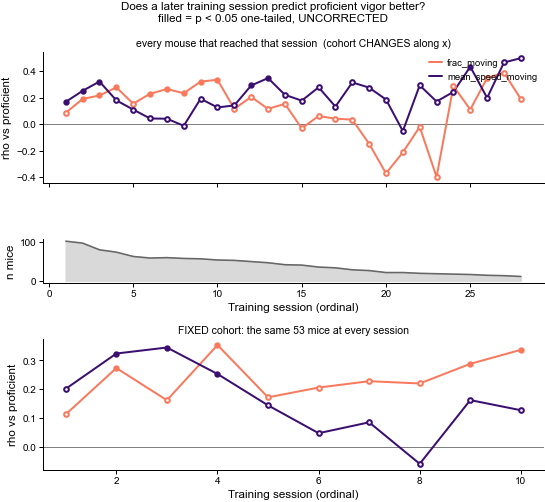


 ord    n         frac_moving   mean_speed_moving
   1  101   +0.088  (p=0.192)   +0.170* (p=0.045)
   2   96   +0.192* (p=0.031)   +0.253* (p=0.006)
   3   79   +0.218* (p=0.027)   +0.323* (p=0.002)
   4   73   +0.279* (p=0.008)   +0.181  (p=0.063)
   5   62   +0.156  (p=0.113)   +0.111  (p=0.194)
   6   58   +0.231* (p=0.041)   +0.044  (p=0.371)
   7   59   +0.267* (p=0.021)   +0.042  (p=0.375)
   8   57   +0.235* (p=0.039)   -0.011  (p=0.532)
   9   56   +0.323* (p=0.008)   +0.193  (p=0.077)
  10   53   +0.337* (p=0.007)   +0.127  (p=0.182)
  11   52   +0.117  (p=0.204)   +0.143  (p=0.156)
  12   49   +0.207  (p=0.077)   +0.293* (p=0.020)
  13   46   +0.117  (p=0.220)   +0.349* (p=0.009)
  14   41   +0.155  (p=0.167)   +0.223  (p=0.080)
  15   40   -0.030  (p=0.573)   +0.179  (p=0.135)
  16   35   +0.063  (p=0.360)   +0.280  (p=0.052)
  17   33   +0.043  (p=0.407)   +0.134  (p=0.229)
  18   28   +0.035  (p=0.430)   +0.316  (p=0.050)
  19   26   -0.147  (p=0.764)   +0.277  (p=0.085)

In [8]:
"""
HOW DOES THE CORRELATION EVOLVE ACROSS TRAINING?
=================================================
A different question from the session-ladder above. That one averaged MORE sessions to
measure the same early state better. This one asks whether a LATER training session
predicts proficient vigor better than an earlier one -- i.e. whether the individual
trait strengthens as the animal learns.

Each point is one training-session ordinal k: take every mouse that has a k-th session,
correlate that single session's metric against the mouse's proficient mean.

TWO THINGS MAKE THE RAW CURVE MISLEADING, AND BOTH ARE DRAWN
  1  n collapses from 101 at session 1 to ~11 by session 28, so the right-hand points
     are extremely noisy. The n curve is plotted underneath for that reason.
  2  SELECTION. A mouse only HAS a 25th training session if it took 25 sessions to
     learn. Late ordinals are therefore a biased subsample of slow learners, and the
     cohort changes identity along the x axis. A downward trend could be entirely
     this.

  The fixed-cohort panel controls for (2): only mice with at least N_FIX sessions are
  used, at every ordinal, so the SAME animals contribute to every point.

Significance is one-tailed and UNCORRECTED, as requested -- with ~28 ordinals x 2
metrics, several stars are expected by chance alone. Read the shape, not the stars.
"""
N_FIX = 10

A = pd.read_parquet('vigor_training_all.parquet')


def per_ordinal(A, cohort=None, min_n=10, max_ord=None):
    rows = []
    for k in sorted(A['ordinal'].dropna().unique()):
        s = A.loc[A['ordinal'] == k].set_index('mouse_name')
        mice = sorted(set(s.index) & set(PROF_M.index) & (set(cohort) if cohort is not None else set(s.index)))
        if len(mice) < min_n or (max_ord and k > max_ord):
            continue
        d = dict(ordinal=int(k), n=len(mice))
        for m in PRIMARY:
            r, pv, n = corr(s.loc[mice, m], PROF_M.loc[mice, m])
            d[f'{m}_rho'], d[f'{m}_p'] = r, pv
        rows.append(d)
    return pd.DataFrame(rows)


PER = per_ordinal(A)
n_long = A.groupby('mouse_name')['ordinal'].max()
FIXED_COHORT = sorted(n_long[n_long >= N_FIX].index)
PER_FIX = per_ordinal(A, cohort=FIXED_COHORT, min_n=8, max_ord=N_FIX)
print(f'raw: ordinals {PER.ordinal.min()}-{PER.ordinal.max()}, n from {PER.n.max()} down to {PER.n.min()}')
print(f'fixed cohort: {len(FIXED_COHORT)} mice with >= {N_FIX} training sessions')

ps.reapply()
LW = plt.rcParams['lines.linewidth']; MS = plt.rcParams['lines.markersize']
COL = {PRIMARY[0]: ps.TIMEPOINT['Early'], PRIMARY[1]: ps.TIMEPOINT['Proficient']}
fig, axes = plt.subplots(3, 1, figsize=(ps.SIZES[ps.MODE]['wide'][0],
                                        ps.SIZES[ps.MODE]['wide'][1] * 1.55),
                         sharex=False, gridspec_kw=dict(height_ratios=[3, 1, 3]))

ax = axes[0]
for m in PRIMARY:
    r = PER[f'{m}_rho'].values; pv = PER[f'{m}_p'].values; x = PER['ordinal'].values
    ax.plot(x, r, '-', color=COL[m], lw=LW, label=m, zorder=2)
    sig = pv < ALPHA
    ax.scatter(x[~sig], r[~sig], s=(MS * .8) ** 2, facecolors='white',
               edgecolors=COL[m], linewidths=LW, zorder=3)
    ax.scatter(x[sig], r[sig], s=(MS * .8) ** 2, color=COL[m], zorder=4)
ps.zero_line(ax)
ax.set_ylabel(f'rho vs proficient')
ax.set_title('every mouse that reached that session  (cohort CHANGES along x)',
             fontsize=plt.rcParams['font.size'] * 0.9)
ax.legend(fontsize=plt.rcParams['font.size'] * 0.8, loc='upper right')
ax.set_xticklabels([])

ax = axes[1]
ax.fill_between(PER['ordinal'], 0, PER['n'], color='0.85')
ax.plot(PER['ordinal'], PER['n'], color='0.4', lw=LW * 0.8)
ax.set_ylabel('n mice'); ax.set_xlabel('Training session (ordinal)')

ax = axes[2]
for m in PRIMARY:
    r = PER_FIX[f'{m}_rho'].values; pv = PER_FIX[f'{m}_p'].values; x = PER_FIX['ordinal'].values
    ax.plot(x, r, '-', color=COL[m], lw=LW, zorder=2)
    sig = pv < ALPHA
    ax.scatter(x[~sig], r[~sig], s=(MS * .8) ** 2, facecolors='white',
               edgecolors=COL[m], linewidths=LW, zorder=3)
    ax.scatter(x[sig], r[sig], s=(MS * .8) ** 2, color=COL[m], zorder=4)
ps.zero_line(ax)
ax.set_ylabel('rho vs proficient'); ax.set_xlabel('Training session (ordinal)')
ax.set_title(f'FIXED cohort: the same {len(FIXED_COHORT)} mice at every session',
             fontsize=plt.rcParams['font.size'] * 0.9)

fig.suptitle('Does a later training session predict proficient vigor better?\n'
             'filled = p < 0.05 one-tailed, UNCORRECTED',
             fontsize=plt.rcParams['font.size'])
fig.tight_layout()
ps.savefig(fig, 'wheelvigor_correlation_across_training', svg=True)
plt.show()

print(f'\n{"ord":>4s} {"n":>4s} ' + ' '.join(f'{m[:17]:>19s}' for m in PRIMARY))
for _, x in PER.iterrows():
    cells = [f'{x[f"{m}_rho"]:+.3f}{"*" if x[f"{m}_p"] < ALPHA else " "} (p={x[f"{m}_p"]:.3f})'
             for m in PRIMARY]
    print(f'{int(x.ordinal):4d} {int(x.n):4d} ' + ' '.join(f'{c:>19s}' for c in cells))

raw cohort: k=1..20, n from 101 to 21
fixed cohort: 53 mice, k=1..10
wrote figures/wheelvigor_cumulative_sessions_12-09-2026.png, figures/wheelvigor_cumulative_sessions_12-09-2026.svg


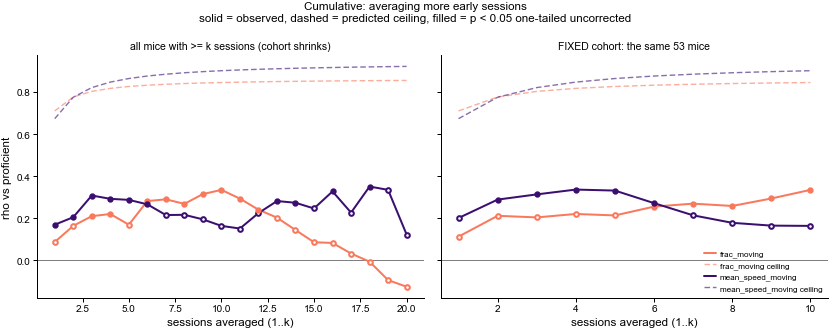


ALL MICE (shrinking cohort)
  k    n                frac_moving           mean_speed_movin
  1  101 +0.088  (p=0.192, ceil 0.71) +0.170* (p=0.045, ceil 0.67)
  2   96 +0.165  (p=0.055, ceil 0.78) +0.206* (p=0.022, ceil 0.78)
  3   79 +0.210* (p=0.031, ceil 0.80) +0.309* (p=0.003, ceil 0.82)
  4   73 +0.221* (p=0.030, ceil 0.82) +0.293* (p=0.006, ceil 0.85)
  5   62 +0.170  (p=0.093, ceil 0.83) +0.288* (p=0.012, ceil 0.86)
  6   58 +0.282* (p=0.016, ceil 0.83) +0.267* (p=0.021, ceil 0.88)
  7   58 +0.290* (p=0.014, ceil 0.84) +0.216  (p=0.052, ceil 0.88)
  8   56 +0.269* (p=0.023, ceil 0.84) +0.217  (p=0.054, ceil 0.89)
  9   55 +0.315* (p=0.010, ceil 0.84) +0.195  (p=0.077, ceil 0.90)
 10   52 +0.335* (p=0.008, ceil 0.85) +0.164  (p=0.122, ceil 0.90)
 11   51 +0.294* (p=0.018, ceil 0.85) +0.152  (p=0.144, ceil 0.90)
 12   48 +0.241* (p=0.049, ceil 0.85) +0.225  (p=0.062, ceil 0.91)
 13   45 +0.203  (p=0.090, ceil 0.85) +0.282* (p=0.030, ceil 0.91)
 14   40 +0.145  (p=0.187, ceil 0.85)

In [9]:
"""
CUMULATIVE: AVERAGE SESSIONS 1..k, THEN CORRELATE
==================================================
The session-ladder cell above, extended to every k rather than just 1, 2, 3.

WHAT THE SHAPE MEANS. Averaging more sessions does not change the mouse -- it measures
the same early state more precisely. So under the attenuation account this curve must
RISE and then PLATEAU, and the plateau height is an estimate of the TRUE correlation,
read off the data rather than extrapolated by Spearman-Brown. That is worth more than
any single corrected number, because it needs no assumption about how reliability
scales.

The dashed line is the predicted ceiling at each k,
    sqrt( r_k * rel_proficient )   with   r_k = k*r1 / (1 + (k-1)*r1)
so the gap between solid and dashed is what is still lost to measurement error.
If the solid curve rises and the dashed one rises WITH it, we are still noise-limited;
if the solid one flattens well below the dashed one, we have hit the real trait.

Both panels again, for the same reason as before: the raw cohort shrinks with k and
late-k mice are slow learners, so the FIXED cohort is the one to interpret.
"""
def cumulative(A, cohort, ks, min_n=8):
    """rho between mean(sessions 1..k) and proficient, per k."""
    rows = []
    for k in ks:
        sub = A.loc[A['ordinal'] <= k]
        cnt = sub.groupby('mouse_name')['ordinal'].nunique()
        elig = [m for m in cohort if cnt.get(m, 0) >= k]        # must HAVE all k
        if len(elig) < min_n:
            continue
        early = sub.loc[sub['mouse_name'].isin(elig)].groupby('mouse_name')[METRICS].mean()
        d = dict(k=int(k), n=len(elig))
        for m in PRIMARY:
            r, pv, n = corr(early.loc[elig, m], PROF_M.loc[elig, m])
            d[f'{m}_rho'], d[f'{m}_p'] = r, pv
            d[f'{m}_ceil'] = np.sqrt(max(sb_k(REL1[m], k), 0) * max(REL_P3[m], 0))
        rows.append(d)
    return pd.DataFrame(rows)


KS = list(range(1, 21))
ALL_MICE = sorted(set(A['mouse_name']) & set(PROF_M.index))
CUM = cumulative(A, ALL_MICE, KS)
CUM_FIX = cumulative(A, FIXED_COHORT, list(range(1, N_FIX + 1)))
print(f'raw cohort: k=1..{CUM.k.max()}, n from {CUM.n.max()} to {CUM.n.min()}')
print(f'fixed cohort: {len(FIXED_COHORT)} mice, k=1..{CUM_FIX.k.max()}')

ps.reapply()
LW = plt.rcParams['lines.linewidth']; MS = plt.rcParams['lines.markersize']
fig, axes = plt.subplots(1, 2, figsize=(ps.SIZES[ps.MODE]['double'][0],
                                        ps.SIZES[ps.MODE]['double'][1] * 0.9), sharey=True)
for ax, D, title in [(axes[0], CUM, 'all mice with >= k sessions (cohort shrinks)'),
                     (axes[1], CUM_FIX, f'FIXED cohort: the same {len(FIXED_COHORT)} mice')]:
    for m in PRIMARY:
        x = D['k'].values; r = D[f'{m}_rho'].values; pv = D[f'{m}_p'].values
        ax.plot(x, r, '-', color=COL[m], lw=LW, label=m, zorder=3)
        ax.plot(x, D[f'{m}_ceil'].values, ls=(0, (4, 2)), color=COL[m],
                lw=LW * 0.7, alpha=0.6, zorder=2,
                label=f'{m} ceiling' if ax is axes[1] else None)
        sig = pv < ALPHA
        ax.scatter(x[~sig], r[~sig], s=(MS * .8) ** 2, facecolors='white',
                   edgecolors=COL[m], linewidths=LW, zorder=4)
        ax.scatter(x[sig], r[sig], s=(MS * .8) ** 2, color=COL[m], zorder=5)
    ps.zero_line(ax)
    ax.set_xlabel('sessions averaged (1..k)')
    ax.set_title(title, fontsize=plt.rcParams['font.size'] * 0.9)
axes[0].set_ylabel('rho vs proficient')
axes[1].legend(fontsize=plt.rcParams['font.size'] * 0.7, loc='lower right')
fig.suptitle('Cumulative: averaging more early sessions\n'
             'solid = observed, dashed = predicted ceiling, filled = p < 0.05 one-tailed uncorrected',
             fontsize=plt.rcParams['font.size'])
fig.tight_layout()
ps.savefig(fig, 'wheelvigor_cumulative_sessions', svg=True)
plt.show()

for lab, D in [('ALL MICE (shrinking cohort)', CUM), ('FIXED COHORT', CUM_FIX)]:
    print(f'\n{lab}')
    print(f'{"k":>3s} {"n":>4s} ' + ' '.join(f'{m[:16]:>26s}' for m in PRIMARY))
    for _, x in D.iterrows():
        cells = [f'{x[f"{m}_rho"]:+.3f}{"*" if x[f"{m}_p"] < ALPHA else " "} '
                 f'(p={x[f"{m}_p"]:.3f}, ceil {x[f"{m}_ceil"]:.2f})' for m in PRIMARY]
        print(f'{int(x.k):3d} {int(x.n):4d} ' + ' '.join(f'{c:>26s}' for c in cells))

wrote figures/wheelvigor_correlation_vs_time_to_proficiency_12-09-2026.png, figures/wheelvigor_correlation_vs_time_to_proficiency_12-09-2026.svg


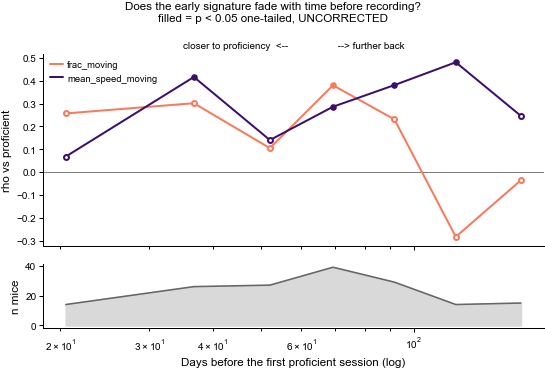

    gap (days)    n  sess          frac_moving     mean_speed_movin
         14-30   14    78    +0.257  (p=0.187)    +0.068  (p=0.408)
         30-45   26   158    +0.302  (p=0.067)    +0.417* (p=0.017)
         45-60   27   168    +0.105  (p=0.301)    +0.140  (p=0.242)
         60-80   39   273    +0.380* (p=0.008)    +0.286* (p=0.039)
        80-105   29   218    +0.231  (p=0.114)    +0.381* (p=0.021)
       105-140   14    69    -0.284  (p=0.837)    +0.481* (p=0.041)
       140-190   15   171    -0.036  (p=0.550)    +0.246  (p=0.188)


In [10]:
"""
CORRELATION AS A FUNCTION OF TIME DISTANCE FROM PROFICIENCY
============================================================
The two previous cells indexed training by ORDINAL -- how many sessions in. This one
indexes by ELAPSED TIME -- how many days before the animal's first proficient
(recording) session. The two are not the same: a mouse that trains for 40 sessions and
one that trains for 12 both end at proficiency, so ordinal 10 sits at very different
distances from the goal for each.

Time distance is arguably the more natural axis for "does individuality decay": it asks
how far back a behavioural signature is still readable, in days, regardless of how many
sessions the animal happened to run.

CONSTRUCTION. For each mouse, the reference is its FIRST proficient session date. Every
training session gets gap = (that date - its own date), in days. Sessions are grouped
into gap bins; within a bin a mouse's sessions are AVERAGED so it contributes once; the
bin's rho is then across mice.

All 1280 training sessions have a date and every gap is positive (14 to 331 days,
median 76), so no session straddles the boundary.

THE SAME SELECTION CAVEAT AS BEFORE, in a new guise. Only a slow learner HAS a session
300 days before its recording, so the far bins are biased toward slow learners and the
cohort identity shifts along x. The n panel is drawn for that reason; read the
left-hand (near-proficiency) bins as the better-supported ones.
"""
import sys as _sys
_sys.path.insert(0, str(_root / 'learning_individuality'))
from session_filters import load_session_table

GAP_EDGES = [14, 30, 45, 60, 80, 105, 140, 190, 340]

_tab = load_session_table().drop_duplicates('eid')
_tab['date'] = pd.to_datetime(_tab['date'], errors='coerce')
_prof_dates = (PROF[['mouse_name', 'session']]
               .merge(_tab[['eid', 'date']], left_on='session', right_on='eid', how='left'))
REF_DATE = _prof_dates.groupby('mouse_name')['date'].min()      # first recording day

G = A.copy()
G['session_date'] = pd.to_datetime(G['session_date'], errors='coerce')
G['ref'] = G['mouse_name'].map(REF_DATE)
G['gap_days'] = (G['ref'] - G['session_date']).dt.days
G = G.dropna(subset=['gap_days'])

rows = []
for lo, hi in zip(GAP_EDGES[:-1], GAP_EDGES[1:]):
    s = G.loc[(G['gap_days'] >= lo) & (G['gap_days'] < hi)]
    per_mouse = s.groupby('mouse_name')[METRICS].mean()          # one value per mouse
    mice = sorted(set(per_mouse.index) & set(PROF_M.index))
    if len(mice) < 10:
        continue
    d = dict(lo=lo, hi=hi, centre=np.sqrt(lo * hi), n=len(mice), n_sess=len(s))
    for m in PRIMARY:
        r, pv, n = corr(per_mouse.loc[mice, m], PROF_M.loc[mice, m])
        d[f'{m}_rho'], d[f'{m}_p'] = r, pv
    rows.append(d)
GAPR = pd.DataFrame(rows)

ps.reapply()
LW = plt.rcParams['lines.linewidth']; MS = plt.rcParams['lines.markersize']
fig, axes = plt.subplots(2, 1, figsize=(ps.SIZES[ps.MODE]['wide'][0],
                                        ps.SIZES[ps.MODE]['wide'][1] * 1.15),
                         gridspec_kw=dict(height_ratios=[3, 1]), sharex=True)
ax = axes[0]
for m in PRIMARY:
    x = GAPR['centre'].values; r = GAPR[f'{m}_rho'].values; pv = GAPR[f'{m}_p'].values
    ax.plot(x, r, '-', color=COL[m], lw=LW, label=m, zorder=3)
    sig = pv < ALPHA
    ax.scatter(x[~sig], r[~sig], s=(MS * .85) ** 2, facecolors='white',
               edgecolors=COL[m], linewidths=LW, zorder=4)
    ax.scatter(x[sig], r[sig], s=(MS * .85) ** 2, color=COL[m], zorder=5)
ps.zero_line(ax)
ax.set_xscale('log')
ax.set_ylabel('rho vs proficient')
ax.legend(fontsize=plt.rcParams['font.size'] * 0.8, loc='best')
ax.set_title('closer to proficiency  <--                  --> further back',
             fontsize=plt.rcParams['font.size'] * 0.85)

ax = axes[1]
ax.fill_between(GAPR['centre'], 0, GAPR['n'], color='0.85')
ax.plot(GAPR['centre'], GAPR['n'], color='0.4', lw=LW * 0.8)
ax.set_ylabel('n mice'); ax.set_xlabel('Days before the first proficient session (log)')
ax.set_xscale('log')
# NOTE: sharex=True means the two axes share one x-axis, so calling invert_xaxis()
# on each of them inverts twice and cancels out. The axis is left in its natural
# order instead -- small gaps (closest to the recording) on the LEFT -- and the title
# says so, rather than carrying an annotation that contradicts the plot.
fig.suptitle('Does the early signature fade with time before recording?\n'
             'filled = p < 0.05 one-tailed, UNCORRECTED',
             fontsize=plt.rcParams['font.size'])
fig.tight_layout()
ps.savefig(fig, 'wheelvigor_correlation_vs_time_to_proficiency', svg=True)
plt.show()

print(f'{"gap (days)":>14s} {"n":>4s} {"sess":>5s} ' + ' '.join(f'{m[:16]:>20s}' for m in PRIMARY))
for _, x in GAPR.iterrows():
    cells = [f'{x[f"{m}_rho"]:+.3f}{"*" if x[f"{m}_p"] < ALPHA else " "} (p={x[f"{m}_p"]:.3f})'
             for m in PRIMARY]
    print(f'{f"{int(x.lo)}-{int(x.hi)}":>14s} {int(x.n):4d} {int(x.n_sess):5d} '
          + ' '.join(f'{c:>20s}' for c in cells))

EXPLORATORY -- linear (computed before the hypothesis was registered)
  vigor source           metric                   rho  p 2-tail    n
  session 1              frac_moving           -0.076    0.4488  101
  session 1              mean_speed_moving     +0.103    0.3071  101
  mean of sessions 1-3   frac_moving           -0.168    0.1388   79
  mean of sessions 1-3   mean_speed_moving     +0.023     0.841   79
  proficient             frac_moving           +0.053    0.5981  101
  proficient             mean_speed_moving     +0.032    0.7534  101

REGISTERED -- quadratic / U-shape on log(sessions to proficiency)
  beta2 > 0 would mean INTERMEDIATE movers learn FASTEST (the prediction)
  vigor source           metric                  beta2         p     dR2    n
  session 1              frac_moving            +0.001    0.9813  +0.000  101
  session 1              mean_speed_moving      -0.010     0.739  +0.001  101
  mean of sessions 1-3   frac_moving            -0.118   0.06447  +0.042

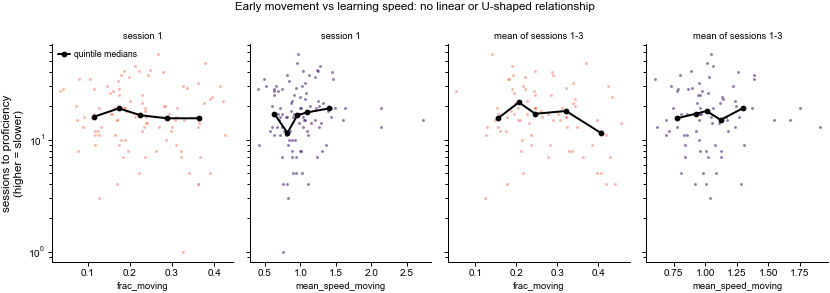

In [11]:
"""
DOES EARLY MOVEMENT PREDICT LEARNING SPEED?
============================================
Hypothesis as stated: animals that spend more time moving, or move more vigorously,
learn the task FASTER -- or the relationship is an inverted U, with intermediate
movers learning fastest.

PROVENANCE, stated plainly. The LINEAR correlations below had already been computed
when this hypothesis was registered, so they are EXPLORATORY, not confirmatory. The
QUADRATIC (U-shape) test had not been run at that point and is a genuine a priori
test. Labelling them differently is the only thing that keeps the distinction real.

LEARNING SPEED = number of training sessions before the first proficient (recording)
session. It is identical (rho = 1.00) to `training_days` in
learning_prediction/training_data_10bins, and correlates 0.96 with total training
trials, so the choice among those three is immaterial. Calendar days to recording is
reported too but is a worse measure -- it includes surgery scheduling and husbandry
gaps, and correlates only 0.38 with session count.

DIRECTION. HIGHER n_sessions = SLOWER learner. So:
    "more movement -> faster learning"  predicts a NEGATIVE linear correlation
    "intermediate is best"              predicts a POSITIVE quadratic coefficient
                                        (a U-shape in n_sessions, minimum in the middle)
"""
SPEED = pd.read_parquet('learning_speed.parquet')
n3 = A.loc[A['ordinal'] <= 3].groupby('mouse_name')['ordinal'].nunique()
EARLY3 = A.loc[A['ordinal'] <= 3].groupby('mouse_name')[METRICS].mean().loc[n3[n3 >= 3].index]
SOURCES = [('session 1', FIRST), ('mean of sessions 1-3', EARLY3), ('proficient', PROF_M)]


def quad_test(x, y):
    """OLS y ~ z + z^2 on standardised x. Returns (beta2, p, delta R2, n)."""
    from scipy.stats import t as tdist
    ok = np.isfinite(x) & np.isfinite(y); x, y = x[ok], y[ok]
    z = (x - x.mean()) / x.std()
    X1 = np.column_stack([np.ones(len(z)), z]); X2 = np.column_stack([X1, z ** 2])
    b1, *_ = np.linalg.lstsq(X1, y, rcond=None); b2, *_ = np.linalg.lstsq(X2, y, rcond=None)
    r1, r2 = y - X1 @ b1, y - X2 @ b2
    n, k = len(y), X2.shape[1]
    se = np.sqrt((r2 @ r2) / (n - k) * np.linalg.inv(X2.T @ X2)[2, 2])
    t = b2[2] / se
    return b2[2], 2 * (1 - tdist.cdf(abs(t), n - k)), \
        (1 - r2.var() / y.var()) - (1 - r1.var() / y.var()), int(n)


print('EXPLORATORY -- linear (computed before the hypothesis was registered)')
print(f'  {"vigor source":22s} {"metric":20s} {"rho":>7s} {"p 2-tail":>9s} {"n":>4s}')
for src, frame in SOURCES:
    mice = sorted(set(frame.index) & set(SPEED.index))
    for m in PRIMARY:
        r, pv = spearmanr(frame.loc[mice, m], SPEED.loc[mice, 'n_sessions'])
        print(f'  {src:22s} {m:20s} {r:+7.3f} {pv:9.4g} {len(mice):4d}'
              + ('  *' if pv < ALPHA else ''))

print('\nREGISTERED -- quadratic / U-shape on log(sessions to proficiency)')
print('  beta2 > 0 would mean INTERMEDIATE movers learn FASTEST (the prediction)')
print(f'  {"vigor source":22s} {"metric":20s} {"beta2":>8s} {"p":>9s} {"dR2":>7s} {"n":>4s}')
for src, frame in SOURCES[:2]:
    mice = sorted(set(frame.index) & set(SPEED.index))
    y = np.log(SPEED.loc[mice, 'n_sessions'].values.astype(float))
    for m in PRIMARY:
        b, pv, g, n = quad_test(frame.loc[mice, m].values.astype(float), y)
        print(f'  {src:22s} {m:20s} {b:+8.3f} {pv:9.4g} {g:+7.3f} {n:4d}'
              + ('  *' if pv < ALPHA else ''))

ps.reapply()
LW = plt.rcParams['lines.linewidth']; MS = plt.rcParams['lines.markersize']
fig, axes = plt.subplots(1, 4, figsize=(ps.SIZES[ps.MODE]['double'][0],
                                        ps.SIZES[ps.MODE]['double'][1] * 0.8), sharey=True)
k = 0
for src, frame in SOURCES[:2]:
    mice = sorted(set(frame.index) & set(SPEED.index))
    y = SPEED.loc[mice, 'n_sessions'].values.astype(float)
    for m in PRIMARY:
        ax = axes[k]; k += 1
        x = frame.loc[mice, m].values.astype(float)
        ax.scatter(x, y, s=(MS * 0.5) ** 2, color=COL[m], alpha=0.55, linewidth=0)
        q = pd.qcut(pd.Series(x), 5, labels=False, duplicates='drop')
        cx = [np.median(x[q.values == i]) for i in sorted(pd.unique(q.dropna()))]
        cy = [np.median(y[q.values == i]) for i in sorted(pd.unique(q.dropna()))]
        ax.plot(cx, cy, 'o-', color='k', lw=LW, ms=MS * 0.7, zorder=4,
                label='quintile medians' if k == 1 else None)
        ax.set_yscale('log')
        ax.set_xlabel(m, fontsize=plt.rcParams['font.size'] * 0.8)
        ax.set_title(src, fontsize=plt.rcParams['font.size'] * 0.8)
axes[0].set_ylabel('sessions to proficiency\n(higher = slower)')
axes[0].legend(fontsize=plt.rcParams['font.size'] * 0.75)
fig.suptitle('Early movement vs learning speed: no linear or U-shaped relationship',
             fontsize=plt.rcParams['font.size'])
fig.tight_layout()
ps.savefig(fig, 'wheelvigor_vs_learning_speed', svg=True)
plt.show()

In [12]:
"""
PREMISE CHECK -- is proficient vigor related to LD1 at all?
===========================================================
The reason to care about vigor was that the proficient LDA work pointed at it. If
LD1 and vigor are unrelated, the pre-registered hypothesis loses its motivation. This
is a VALIDITY CHECK, not a hypothesis test: it is exploratory, two-tailed, across all
metrics, and would not survive correction.

THE SIGN OF LD1 IS ARBITRARY. Two LDA files from the same pipeline give LD1s that
correlate at -0.986: the same axis with opposite conventions. Only |rho| is
interpretable, and no ONE-tailed test against LD1 is legitimate without anchoring the
orientation to something external -- orienting it so that vigor comes out positive and
then testing whether vigor is positive would be circular.

What IS sign-invariant, and was predicted in advance: frac_moving and
mean_speed_moving load on LD1 with OPPOSITE signs. That was implied by the earlier
observation that mean_speed mixes the two constructs -- if the two parts load
oppositely, the mixture cancels. mean_speed's near-zero loading below is that
prediction coming true.
"""
from pathlib import Path

LDA_CANDIDATES = [
    _root / 'clustering' / 'data_files' / 'mouse_LDA_5_bins_cut08-09-2026',
    _root / 'clustering' / 'data_files' / 'mouse_LDA_5_bins_cut19-06-2026',
]
_lda_path = next((p for p in LDA_CANDIDATES if p.exists()), None)
if _lda_path is None:
    print('no LDA file found -- skipping the premise check')
else:
    lda = pd.read_pickle(_lda_path)
    lda = lda.loc[lda['mouse_name'] != 'PL034']
    ld1 = lda.groupby('mouse_name')[0].mean()          # column 0 = LD1, as elsewhere
    mice = sorted(set(ld1.index) & set(PROF_M.index))
    print(f'{_lda_path.name}  |  {len(mice)} mice')
    print(f'  {"metric":22s} {"rho":>7s} {"|rho|":>7s} {"p 2-tail":>9s}')
    for m in METRICS:
        r, p = spearmanr(ld1.loc[mice], PROF_M.loc[mice, m])
        tag = '  <- CO-PRIMARY' if m in PRIMARY else ''
        print(f'  {m:22s} {r:+7.3f} {abs(r):7.3f} {p:9.4g}{tag}')
    print('\n  signs are relative only. The robust statement is that the two')
    print('  co-primaries load on LD1 in OPPOSITE directions.')

mouse_LDA_5_bins_cut08-09-2026  |  55 mice
  metric                     rho   |rho|  p 2-tail
  mean_speed              -0.024   0.024    0.8626
  mean_speed_moving       +0.347   0.347  0.009389  <- CO-PRIMARY
  median_speed            -0.226   0.226   0.09724
  p95_speed               +0.125   0.125    0.3639
  sd_speed                +0.178   0.178    0.1939
  frac_moving             -0.194   0.194    0.1566  <- CO-PRIMARY
  bout_rate_per_min       -0.155   0.155    0.2581
  mean_bout_s             +0.121   0.121    0.3783
  distance_per_min        -0.024   0.024    0.8626
  mean_vel_signed         +0.081   0.081    0.5568
  turn_bias               -0.021   0.021    0.8795

  signs are relative only. The robust statement is that the two
  co-primaries load on LD1 in OPPOSITE directions.


In [13]:
""" CONFOUND CHECKS -- a correlation about session length is not about the mouse. """
print('Do the co-primary metrics track a nuisance variable?')
print(f'{"nuisance":16s} ' + ' '.join(f'{m[:14]:>16s}' for m in PRIMARY))
prof_nuis = PROF.groupby('mouse_name').mean(numeric_only=True)
for nz in ['duration_min', 'n_samples', 'sampling_hz']:
    cells = []
    for m in PRIMARY:
        a = spearmanr(FIRST.loc[COH1, m], FIRST.loc[COH1, nz], nan_policy='omit')[0]
        b = spearmanr(PROF_M.loc[COH1, m], prof_nuis.loc[COH1, nz], nan_policy='omit')[0]
        cells.append(f'{a:+.2f}/{b:+.2f}')
    print(f'{nz:16s} ' + ' '.join(f'{c:>16s}' for c in cells))
print('  (early / proficient)')

print('\nPartial correlation, controlling session duration on both sides:')
from scipy.stats import rankdata
for m in PRIMARY:
    x = rankdata(FIRST.loc[COH1, m]); y = rankdata(PROF_M.loc[COH1, m])
    a = rankdata(FIRST.loc[COH1, 'duration_min'])
    b = rankdata(prof_nuis.loc[COH1, 'duration_min'])
    rx = x - np.polyval(np.polyfit(a, x, 1), a)
    ry = y - np.polyval(np.polyfit(b, y, 1), b)
    r0 = corr(FIRST.loc[COH1, m], PROF_M.loc[COH1, m])[0]
    rp, pp = pearsonr(rx, ry)
    print(f'  {m:22s} raw {r0:+.3f}  ->  partial {rp:+.3f}  (p={pp:.4g})')
print('  a large drop would mean the effect is session length, not the animal.')

Do the co-primary metrics track a nuisance variable?
nuisance              frac_moving   mean_speed_mov
duration_min          -0.05/-0.12      -0.13/+0.11
n_samples             -0.05/-0.12      -0.13/+0.11
sampling_hz            +nan/-0.06       +nan/-0.02
  (early / proficient)

Partial correlation, controlling session duration on both sides:
  frac_moving            raw +0.088  ->  partial +0.063  (p=0.5304)
  mean_speed_moving      raw +0.170  ->  partial +0.157  (p=0.1157)
  a large drop would mean the effect is session length, not the animal.


/opt/anaconda3/envs/learning_variability/lib/python3.8/site-packages/scipy/stats/_stats_py.py:4881: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))
/opt/anaconda3/envs/learning_variability/lib/python3.8/site-packages/scipy/stats/_stats_py.py:4881: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


wrote figures/wheelvigor_first_vs_proficient_12-09-2026.png, figures/wheelvigor_first_vs_proficient_12-09-2026.svg


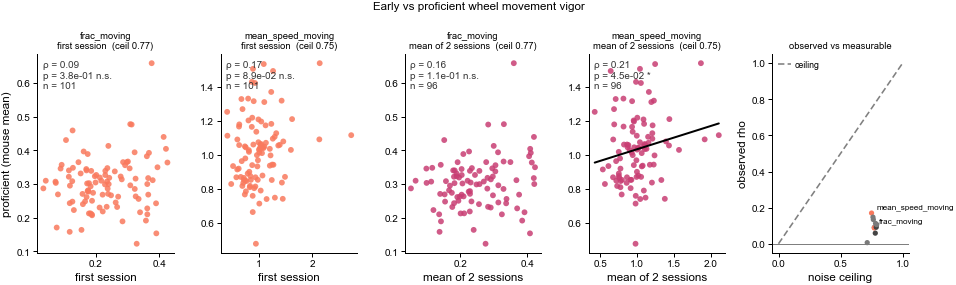

In [14]:
""" FIGURE -- co-primaries under both analyses, and every metric against its ceiling. """
ps.reapply()
MS = plt.rcParams['lines.markersize']
fig, axes = plt.subplots(1, 5, figsize=(ps.SIZES[ps.MODE]['double'][0] * 1.15,
                                        ps.SIZES[ps.MODE]['double'][1] * 0.78))
for k, (m, early, cohort, lab) in enumerate([
        (PRIMARY[0], FIRST, COH1, 'first session'),
        (PRIMARY[1], FIRST, COH1, 'first session'),
        (PRIMARY[0], EARLY2, COH2, 'mean of 2 sessions'),
        (PRIMARY[1], EARLY2, COH2, 'mean of 2 sessions')]):
    ax = axes[k]
    r, p, n = corr(early.loc[cohort, m], PROF_M.loc[cohort, m])
    ps.corr_panel(ax, early.loc[cohort, m], PROF_M.loc[cohort, m],
                  color=ps.TIMEPOINT['Early'] if k < 2 else ps.TIMEPOINT['Late'],
                  method=METHOD, xlabel=lab,
                  ylabel='proficient (mouse mean)' if k == 0 else None)
    ax.set_title(f'{m}\n{lab}  (ceil {CEILING[m]:.2f})',
                 fontsize=plt.rcParams['font.size'] * 0.8)

ax = axes[4]
rs = [corr(FIRST.loc[COH1, m], PROF_M.loc[COH1, m])[0] for m in METRICS]
cs = [CEILING[m] for m in METRICS]
cols = [ps.TIMEPOINT['Early'] if m in PRIMARY else
        ('#444444' if m in SECONDARY else ps.NEUTRAL) for m in METRICS]
ax.scatter(cs, rs, c=cols, s=(MS * 0.9) ** 2, zorder=3)
lim = [0, 1.0]
ax.plot(lim, lim, ls=(0, (4, 2)), color='0.5',
        lw=plt.rcParams['lines.linewidth'] * 0.8, label='ceiling')
ps.zero_line(ax)
for m, c_, r_ in zip(METRICS, cs, rs):
    if m in PRIMARY:
        ax.annotate(m, (c_, r_), fontsize=plt.rcParams['font.size'] * 0.7,
                    xytext=(3, 3), textcoords='offset points')
ax.set_xlabel('noise ceiling'); ax.set_ylabel('observed rho')
ax.set_title('observed vs measurable', fontsize=plt.rcParams['font.size'] * 0.8)
ax.legend(fontsize=plt.rcParams['font.size'] * 0.75)

fig.suptitle('Early vs proficient wheel movement vigor',
             fontsize=plt.rcParams['font.size'])
fig.tight_layout()
ps.savefig(fig, 'wheelvigor_first_vs_proficient', svg=True)
plt.show()

## Results

**Early reliability is high — which is the finding that makes everything else readable.**
A mouse's first training session predicts its *second* at rho = 0.46–0.68, giving ceilings
of 0.75–0.79. Every earlier version of this question assumed the single early session was
near-unmeasurable; it is not. That assumption was wrong, and it was only testable once the
second session was loaded.

**Registered result (first session only, 101 mice): neither co-primary is supported.**
`mean_speed_moving` reaches rho = +0.170 (one-tailed p = 0.045) but does not survive Holm
over the two co-primaries. `frac_moving` is +0.088, p = 0.19.

**Sensitivity (mean of two sessions, 96 mice):** `mean_speed_moving` rises to +0.206 and
clears correction (Holm p = 0.045); `frac_moving` reaches +0.165 (p = 0.055), just short.
The rise is expected — averaging two sessions raises early reliability and so the ceiling.

**The effect is real but small, and the high ceiling lets us say so.** Observed rho ≈ 0.21
against a ceiling of 0.75 means the attenuation-corrected correlation is ≈ 0.27. This is
*not* a strong trait hidden behind noise; early vigor explains roughly 7% of the variance
in proficient vigor. That is a more useful answer than the syllable analyses produced,
precisely because the ceiling is high enough to distinguish "weak" from "unmeasured".

**The half of the hypothesis that works is not the half it led with.** Vigor
(`mean_speed_moving`) carries the relationship — early→proficient, and to LD1 (|rho| = 0.35,
p = 0.009). Time-spent-moving (`frac_moving`), the original primary, is weaker on both
counts and never reaches significance.

### What to be careful about

- The **registered** analysis is null. The significant result is the two-session sensitivity
  analysis, which was added after interim results were seen. Holm p = 0.045 is marginal.
- One of two co-primaries crossing at n = 96 is suggestive, not settled.
- The LD1 premise check is exploratory across 11 metrics and would not survive correction;
  it justifies the hypothesis, it does not confirm anything.

### Next check, if this is to be leaned on

A third early session. 79 mice have one on disk. Adding it should raise early reliability
further and makes a specific, falsifiable prediction: `mean_speed_moving` should rise again,
toward its corrected value of ~0.27. If it does not, the two-session result was noise.